# Local Model Playground

Interactive notebook to pick a local VLM and run a single 2AFC trial on GPU.

In [1]:
# Cell 1 — Setup & imports
import os
import sys
from pathlib import Path

# Ensure the repo root is on sys.path so we can import evaluation_pipe
REPO_ROOT = str(Path.cwd().parent)
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

from dotenv import load_dotenv
load_dotenv()  # loads HF_TOKEN, IMAGE_DATASET, etc.

from PIL import Image
from IPython.display import display, HTML

from evaluation_pipe.models import create_model, list_models
from evaluation_pipe.models.base import ModelResponse

IMAGE_DATASET = Path(os.environ["IMAGE_DATASET"])
print(f"Imports OK — IMAGE_DATASET={IMAGE_DATASET}")

/home/julio/miniforge3/envs/hackathon/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports OK — IMAGE_DATASET=/spark2/julio/langcog_hackathon/data/temp_images


In [2]:
# Cell 2 — Choose model
print("Available models:", list_models())

# ---- Edit these to change model / device ----
MODEL_NAME = "smolvlm"
DEVICE = "cuda"

Available models: ['internvl', 'smolvlm', 'tinyllava']


In [3]:
# Cell 3 — Load model
model = create_model(MODEL_NAME, device=DEVICE)
print(f"Loaded model: {model.name}  (device={DEVICE})")

`torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 657/657 [00:00<00:00, 2891.01it/s]


Loaded model: HuggingFaceTB/SmolVLM2-2.2B-Instruct  (device=cuda)


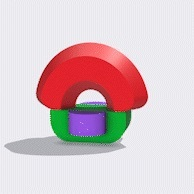

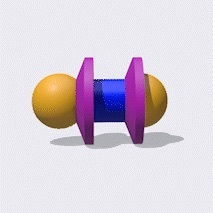

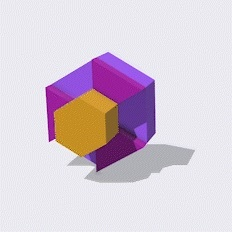

In [4]:
# Cell 4 — Prepare trial images
#
# Loads images from IMAGE_DATASET defined in .env
# Edit filenames below to use different stimuli.

reference = Image.open(IMAGE_DATASET / "1.jpeg").convert("RGB")
image_a   = Image.open(IMAGE_DATASET / "2.jpeg").convert("RGB")
image_b   = Image.open(IMAGE_DATASET / "3.jpeg").convert("RGB")

# Display side-by-side
display(HTML("<b>Reference (1.jpeg) &nbsp; | &nbsp; Image A (2.jpeg) &nbsp; | &nbsp; Image B (3.jpeg)</b>"))
display(reference, image_a, image_b)

In [5]:
# Cell 5 — Define prompt
PROMPT = (
    "You are given three images. The first image is the reference. "
    "Which of the other two images (A or B) is more similar to the reference? "
    "Answer with just 'A' or 'B'."
)

In [6]:
# Cell 6 — Run single trial
response: ModelResponse = model.generate(
    images=[reference, image_a, image_b],
    prompt=PROMPT,
)

print(f"Raw text:        {response.raw_text}")
print(f"Generation time: {response.generation_time_s:.2f}s")
print(f"Model:           {response.model_name}")
print(f"Tokens:          {response.num_tokens_generated}")

Raw text:        B
Generation time: 2.81s
Model:           HuggingFaceTB/SmolVLM2-2.2B-Instruct
Tokens:          2


In [7]:
# Cell 7 — Cleanup
model.unload()
print("Model unloaded — GPU memory freed.")

Model unloaded — GPU memory freed.
